<a href="https://colab.research.google.com/github/FebriansyahMonanda83/Data_Science_252420021/blob/main/STUDY_KASUS_252420021.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Load data
df = pd.read_excel('/content/drive/My Drive/DPT_1606/142.xlsx')

# Standardisasi kolom
df.columns = [c.strip().replace(' ', '_').upper() for c in df.columns]

print("Jumlah data:", len(df))
df.head()

Jumlah data: 526372


,KEC_ID,KECAMATAN,KEL_ID,KELURAHAN,DPID,NKK,NIK,NAMA,TEMPAT_LAHIR,TANGGAL_LAHIR,...,K2,K3,UPDATED_AT,STATUS,RANK,TAHAPAN_ID,PROV_ASAL,KAB_ASAL,KEC_ASAL,KEL_ASAL
0,1897,BABAT SUPAT,26685,BABAT BANYUASIN,621119,1304122510190001,1606145511990001,AYU WANDIRA,MUSI BANYUASIN,1999-11-15,...,NaN,NaN,2025-06-12,baru,baru,24,NaN,NaN,NaN,NaN
1,1897,BABAT SUPAT,26685,BABAT BANYUASIN,653479,1371100607070102,1371104303710006,SUSRIANI,SURIAN,1971-03-03,...,NaN,NaN,2025-11-03,baru,baru,26,NaN,NaN,NaN,NaN
2,1897,BABAT SUPAT,26685,BABAT BANYUASIN,590513,1371100801240001,1371102402990001,FINNY FEBRIANYSA,PADANG,1999-02-24,...,NaN,NaN,2024-08-03,baru,baru,2,NaN,NaN,NaN,NaN
3,1897,BABAT SUPAT,26685,BABAT BANYUASIN,590514,1371100801240001,1304103108950001,ASMAKA INSIA,MALINTANG,1995-08-31,...,NaN,NaN,2024-08-03,baru,baru,2,NaN,NaN,NaN,NaN
4,1897,BABAT SUPAT,26685,BABAT BANYUASIN,7972,1402070601130002,1402070412570001,USMAN,BANYUASIN,1957-12-04,...,NaN,NaN,2024-06-07,aktif,aktif,1,NaN,NaN,NaN,NaN


In [ ]:
# Konversi tanggal lahir
df['TANGGAL_LAHIR'] = pd.to_datetime(df['TANGGAL_LAHIR'], errors='coerce')

# Hapus data tidak valid
df = df.dropna(subset=['TANGGAL_LAHIR'])

# Hitung usia
df['USIA'] = 2026 - df['TANGGAL_LAHIR'].dt.year

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Kategori generasi
def kategori_gen(u):
    if u <= 27: return 'Gen Z'
    elif u <= 43: return 'Milenial'
    elif u <= 59: return 'Gen X'
    else: return 'Baby Boomer'

df['GENERASI'] = df['USIA'].apply(kategori_gen)

# Disabilitas
map_dis = {
    '0': 'Non', '1': 'Fisik', '2': 'Intelektual',
    '3': 'Mental', '4': 'Wicara', '5': 'Rungu', '6': 'Netra'
}

df['DISABILITAS'] = df['DISABILITAS'].fillna('0').astype(str)
df['LABEL_DISABILITAS'] = df['DISABILITAS'].map(map_dis)
df['IS_DISABILITAS'] = df['DISABILITAS'].apply(lambda x: 0 if x == '0' else 1)

In [ ]:
tps = df.groupby('TPS').agg({
    'NIK': 'count',
    'IS_DISABILITAS': 'sum',
    'USIA': 'mean'
}).rename(columns={
    'NIK': 'TOTAL_PEMILIH',
    'USIA': 'RATA_USIA'
})

tps['PROPORSI_DISABILITAS'] = tps['IS_DISABILITAS'] / tps['TOTAL_PEMILIH']

In [ ]:
tps = df.groupby('TPS').agg({
    'NIK': 'count',
    'IS_DISABILITAS': 'sum',
    'USIA': 'mean'
}).rename(columns={
    'NIK': 'TOTAL_PEMILIH',
    'USIA': 'RATA_USIA'
})

tps['PROPORSI_DISABILITAS'] = tps['IS_DISABILITAS'] / tps['TOTAL_PEMILIH']

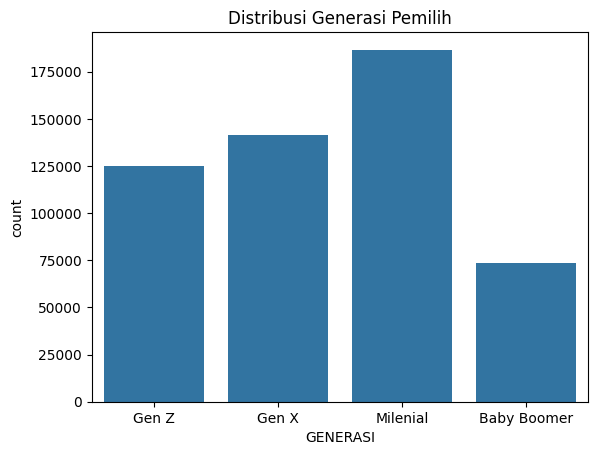

In [ ]:
sns.countplot(data=df, x='GENERASI')
plt.title("Distribusi Generasi Pemilih")
plt.show()

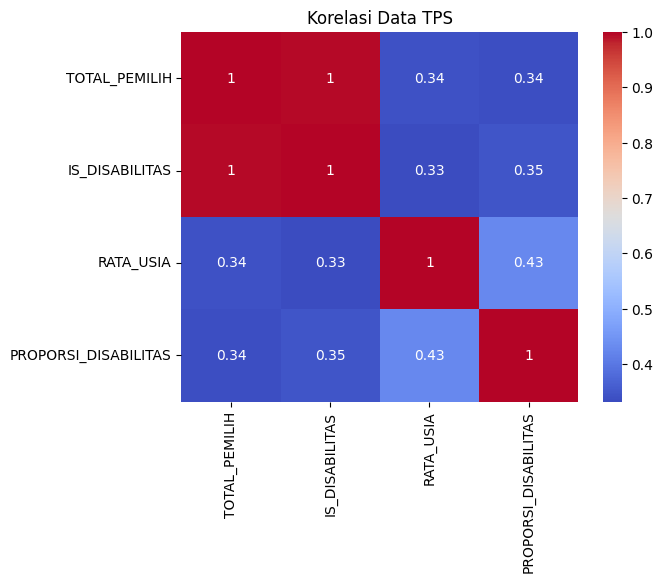

In [ ]:
sns.heatmap(tps.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Korelasi Data TPS")
plt.show()

In [ ]:
np.random.seed(42)

tps['DURASI'] = (
    tps['TOTAL_PEMILIH'] * 2 +
    tps['IS_DISABILITAS'] * 3 +
    tps['RATA_USIA'] * 0.1 +
    np.random.normal(0, 10, len(tps))
)

In [ ]:
X = tps[['TOTAL_PEMILIH', 'IS_DISABILITAS', 'PROPORSI_DISABILITAS', 'RATA_USIA']]
y = tps['DURASI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.9999999951256909
MAE: 5.89452430466864


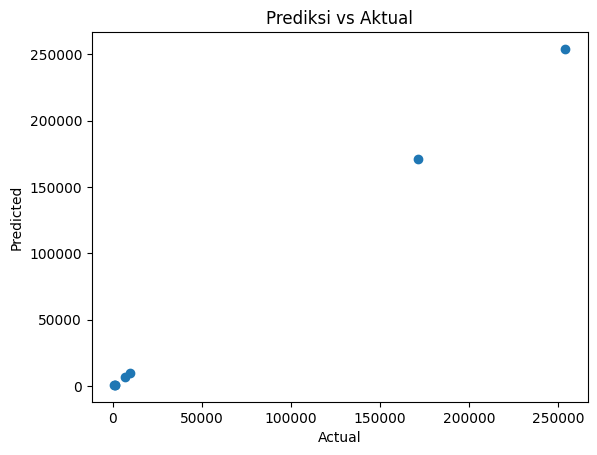

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediksi vs Aktual")
plt.show()

In [ ]:
turnout = {
    'Gen Z': 0.70,
    'Milenial': 0.75,
    'Gen X': 0.85,
    'Baby Boomer': 0.90
}

def simulasi(df, n=300):
    hasil = []
    for _ in range(n):
        hadir = df['GENERASI'].apply(
            lambda g: 1 if np.random.rand() < turnout[g] else 0
        ).sum()
        hasil.append(hadir)
    return hasil

hasil_simulasi = simulasi(df)

print("Rata-rata hadir:", int(np.mean(hasil_simulasi)))

Rata-rata hadir: 413726


In [22]:
import folium

# Jika belum ada koordinat → buat dummy (opsional)
if 'LAT' not in df.columns:
    np.random.seed(42)
    df['LAT'] = -2.9 + np.random.normal(0, 0.05, len(df))
    df['LON'] = 104.7 + np.random.normal(0, 0.05, len(df))

# Agregasi TPS + koordinat
tps_map = df.groupby('TPS').agg({
    'LAT': 'mean',
    'LON': 'mean',
    'NIK': 'count',
    'IS_DISABILITAS': 'sum'
}).rename(columns={'NIK': 'TOTAL_PEMILIH'})

# Buat peta
m = folium.Map(location=[df['LAT'].mean(), df['LON'].mean()], zoom_start=12)

# Tambahkan marker
for _, row in tps_map.iterrows():
    folium.CircleMarker(
        location=[row['LAT'], row['LON']],
        radius=row['TOTAL_PEMILIH'] / 50,
        popup=f"TPS\nPemilih: {row['TOTAL_PEMILIH']}\nDisabilitas: {row['IS_DISABILITAS']}",
        color='blue',
        fill=True
    ).add_to(m)

m

In [20]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Fitur untuk clustering
X_cluster = tps[['TOTAL_PEMILIH', 'IS_DISABILITAS', 'PROPORSI_DISABILITAS']]

# Normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
tps['CLUSTER'] = kmeans.fit_predict(X_scaled)

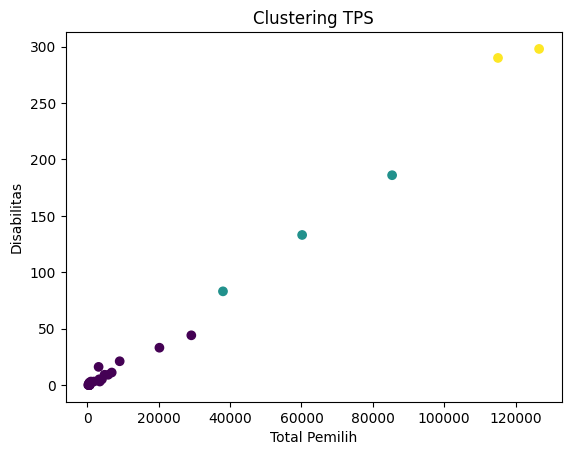

In [21]:
import matplotlib.pyplot as plt

plt.scatter(tps['TOTAL_PEMILIH'], tps['IS_DISABILITAS'], c=tps['CLUSTER'])
plt.xlabel("Total Pemilih")
plt.ylabel("Disabilitas")
plt.title("Clustering TPS")
plt.show()

In [23]:
colors = ['blue', 'red', 'green']

m = folium.Map(location=[df['LAT'].mean(), df['LON'].mean()], zoom_start=12)

for _, row in tps_map.join(tps['CLUSTER']).iterrows():
    folium.CircleMarker(
        location=[row['LAT'], row['LON']],
        radius=6,
        color=colors[int(row['CLUSTER'])],
        fill=True,
        popup=f"TPS Cluster {row['CLUSTER']}"
    ).add_to(m)

m

2026-04-20 14:16:41.307 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 14:16:41.308 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 14:16:41.310 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 14:20:33.276 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 14:20:33.279 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 14:20:33.282 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 14:20:33.283 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 14:20:33.284 Session state does not function when running a script without `streamlit run`
2026-04-20 14:20

DeltaGenerator()

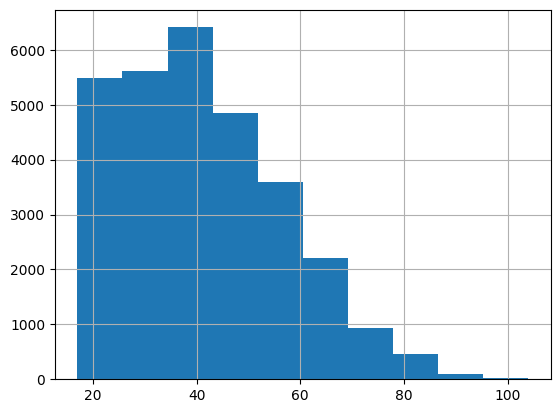

In [26]:
# Install Streamlit (if not already installed)
!pip install streamlit

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.title("Dashboard Analisis TPS")

# Load data
df = pd.read_excel("/content/drive/My Drive/DPT_1606/142.xlsx")

df.columns = [c.strip().replace(' ', '_').upper() for c in df.columns]

# Hitung usia
df['TANGGAL_LAHIR'] = pd.to_datetime(df['TANGGAL_LAHIR'], errors='coerce')
df['USIA'] = 2026 - df['TANGGAL_LAHIR'].dt.year

# Sidebar filter
kecamatan = st.sidebar.selectbox("Pilih Kecamatan", df['KECAMATAN'].unique())
df_filter = df[df['KECAMATAN'] == kecamatan]

st.write("Jumlah Data:", len(df_filter))

# Grafik Generasi
st.subheader("Distribusi Generasi")
fig, ax = plt.subplots()
df_filter['USIA'].hist(ax=ax)
st.pyplot(fig)

# TPS Summary
tps = df_filter.groupby('TPS')['NIK'].count()
st.subheader("Jumlah Pemilih per TPS")
st.bar_chart(tps)